Thinking...
Thinking...
Thinking...
Using file: C:\Users\cacam\Downloads\seis_2026-07-23_11.3mph.csv


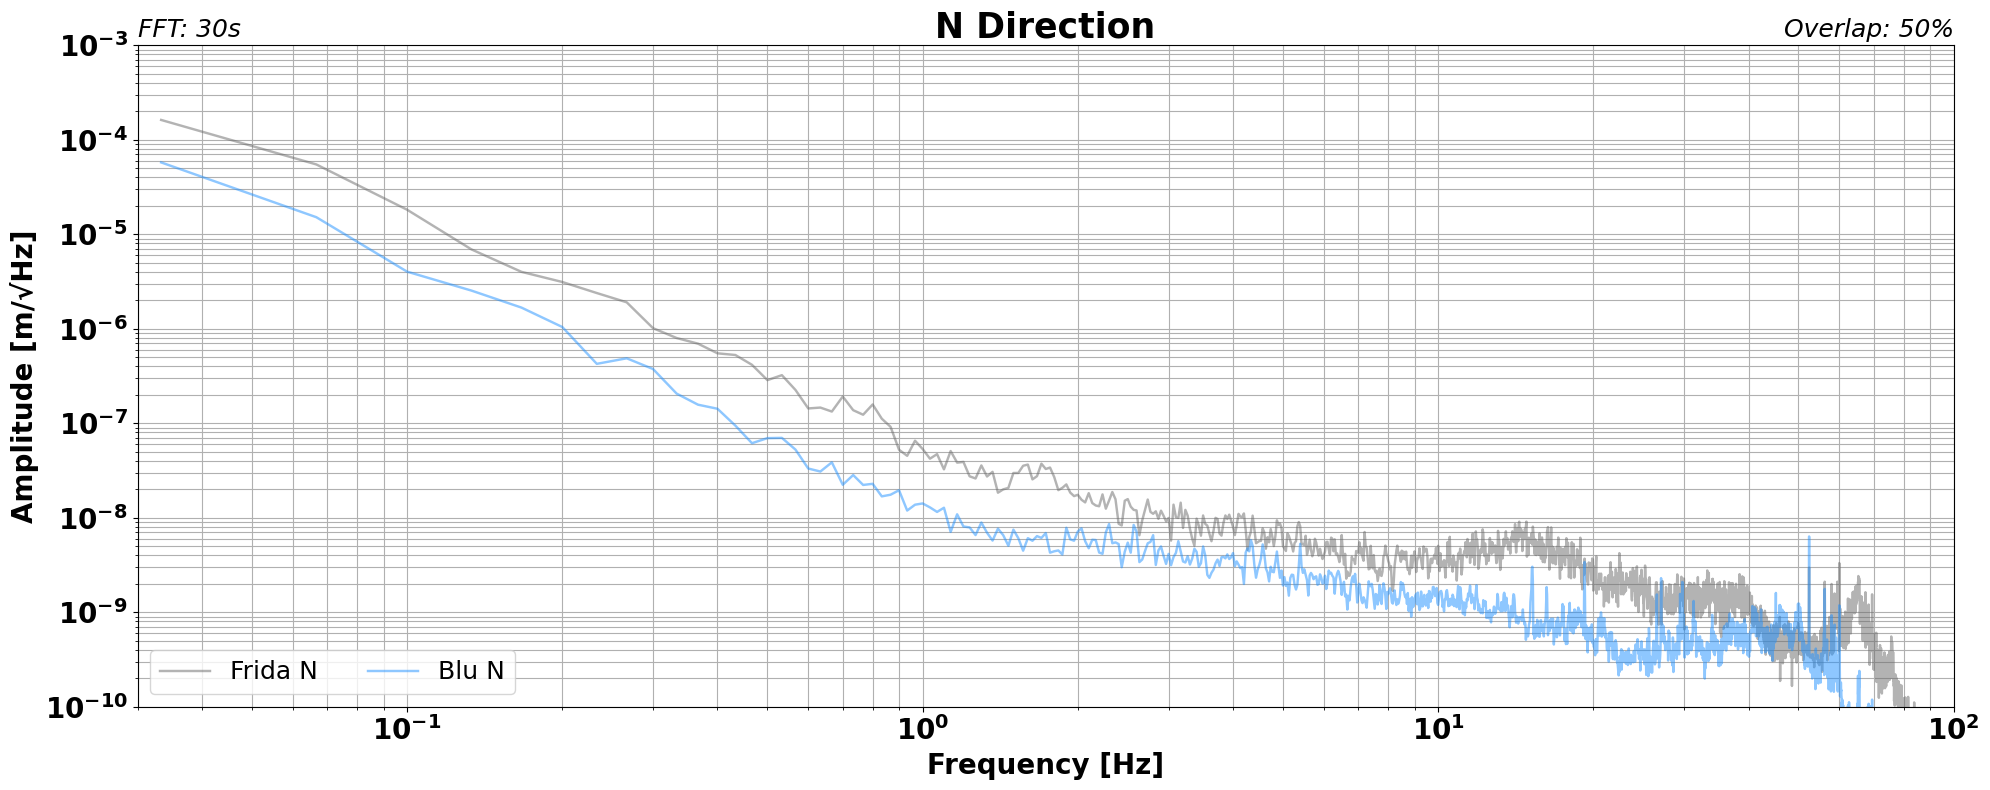

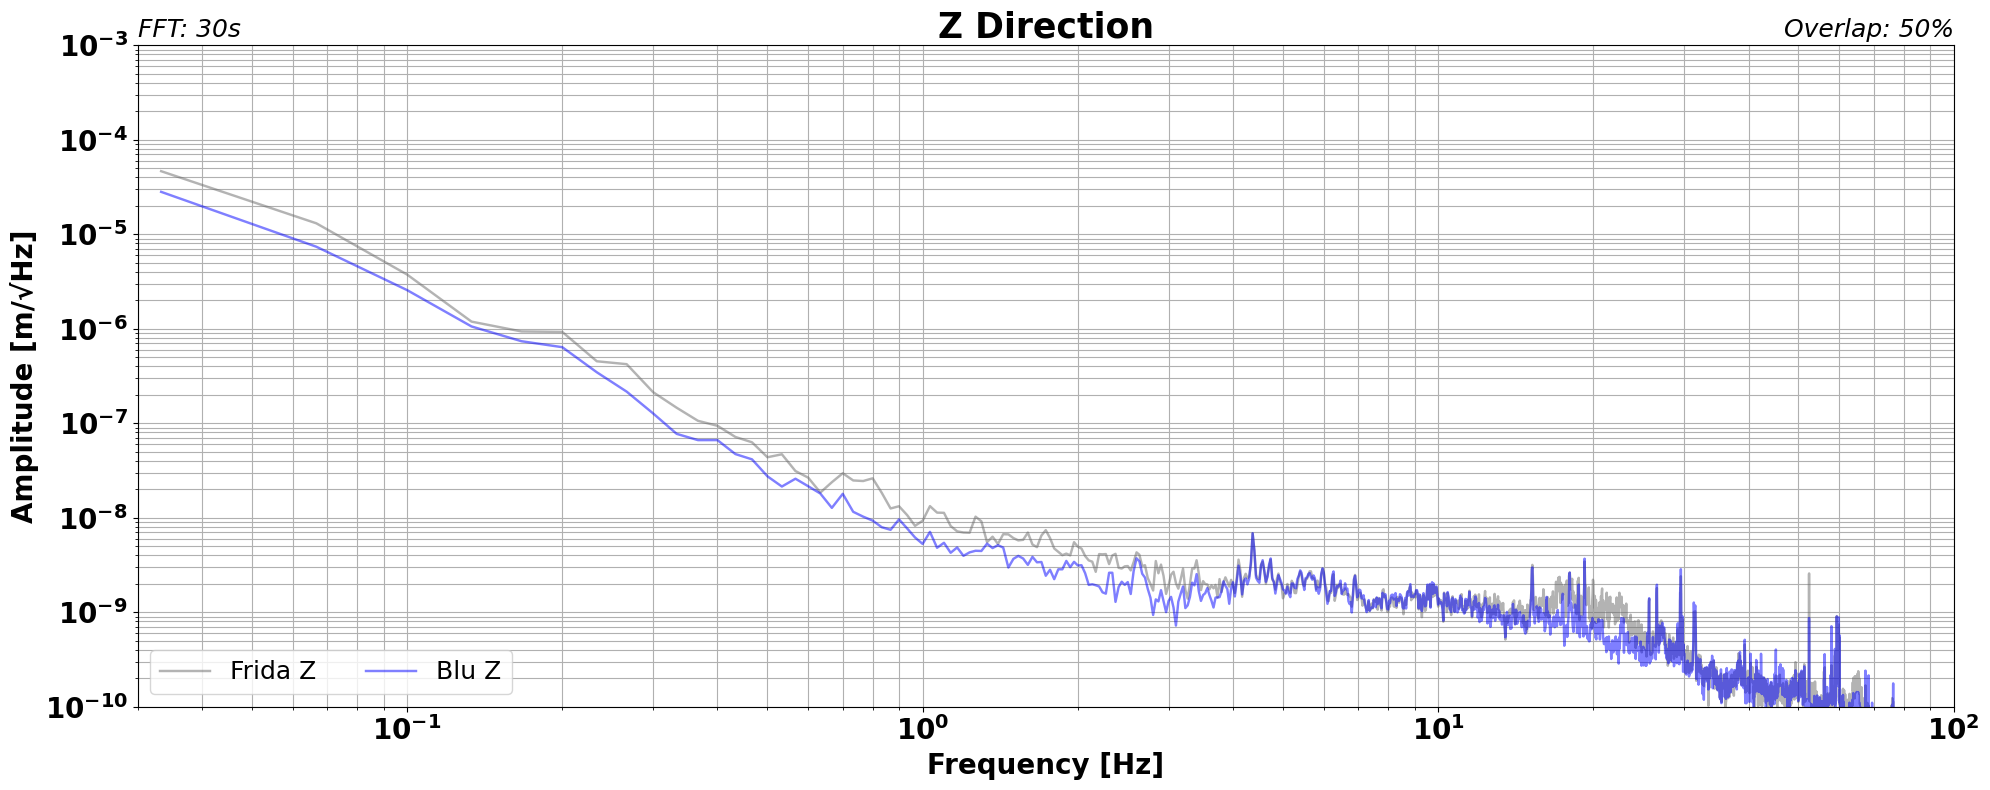

In [16]:
###--------------------------------------------------------------------------------------------------------------------------###
'''------------------------------------------------- SECTION 1 — FILE PATH --------------------------------------------------'''
###--------------------------------------------------------------------------------------------------------------------------###



data_file_path = r"C:\Users\cosmi\Downloads\seis_2026-07-23_11.3mph.csv"


## Is the Frida on channels 1 and 2?                  ## Do you want to look at the most recent download?
cali_seis  = True;                                    most_recent = True

###--------------------------------------------------------------------------------------------------------------------------###
'''----------------------------------------------- SECTION 2 — PLOT SETTINGS ------------------------------------------------'''
###--------------------------------------------------------------------------------------------------------------------------###


# FFT (spectral analysis) settings:
fft_length = 30

# FFT % overlap
overlap    = 50


# Y-axis (amplitude) range:
y_max = 1e-3
y_min = 1e-10



# X-axis (frequency) range in Hz:
x_max = 100
x_min = 0.03

###--------------------------------------------------------------------------------------------------------------------------###

###--------------------------------------------------------------------------------------------------------------------------###


print("Thinking...")
import warnings
import pandas as pd                    # For reading CSV files into tables
import numpy as np                     # For numerical calculations
print("Thinking...")
from scipy import signal               # For the Welch PSD / spectral analysis
from matplotlib import pyplot as plt   # For creating plots
import os
import time
print("Thinking...")
import tkinter as tk
from tkinter import filedialog
from matplotlib import gridspec
from matplotlib.colors import LogNorm
import glob

## ---------------- Select the data file (auto or manual) ---------------- ##

if most_recent == True:

    downloads_folder = os.path.join(os.path.expanduser("~"), "Downloads")

    ## Grab every CSV in Downloads. The *.csv pattern already excludes
    ## in-progress downloads like .crdownload/.tmp, but browsers sometimes
    ## finish a rename before the file is fully flushed to disk — so also
    ## confirm the file size isn't still changing before we trust it.
    csv_files = glob.glob(os.path.join(downloads_folder, "*.csv"))

    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {downloads_folder}")

    data_file_path = max(csv_files, key=os.path.getmtime)

    size_before = os.path.getsize(data_file_path)
    time.sleep(1)
    size_after = os.path.getsize(data_file_path)

    if size_before != size_after:
        raise RuntimeError(
            f"{os.path.basename(data_file_path)} still appears to be downloading — "
            "wait for it to finish and re-run."
        )

else:
    ## Manual path was provided above — make sure it actually exists
    if not os.path.isfile(data_file_path):
        raise FileNotFoundError(f"File not found: {data_file_path}")

## Let the user know which file is actually being used, either way
print(f"Using file: {data_file_path}")

warnings.simplefilter('ignore')



###--------------------------------------------------------------------------------------------------------------------------###
'''------------------------------------------ SECTION 4 — READ THE FIELD DATA FILE ------------------------------------------'''
###--------------------------------------------------------------------------------------------------------------------------###


## --------------- Read metadata (first 5 lines) -------------- ##
metadata = {}
with open(data_file_path, 'r') as f:
    for _ in range(5):
        line = f.readline().strip()
        if ':' in line:
            key, value = line.split(':', 1)
            metadata[key.strip()] = value.strip()

sample_rate = float(metadata["Sample Rate"])


## -------------- Read the seismic data columns --------------- ##

raw_data = pd.read_csv(data_file_path, skiprows=5, delimiter=',')


if cali_seis == True:
    raw_data.columns = ["Sample", "Time (s)", 
                        "Frida N", "Frida Z", 
                        "Blu N", "Blu Z", 
                        "blank"]
else:
    raw_data.columns = ["Sample", "Time (s)", 
                        "Blu N", "Blu Z", 
                        "Frida N", "Frida Z", 
                        "blank"]


## --- Apply calibration factor (Volts → meters per second) --- ##
cali_40T = 0.0015167
cali_3T  = 0.0006857

frida_n   = raw_data["Frida N"] * cali_40T   # 
frida_z   = raw_data["Frida Z"] * cali_40T   # 
blu_n   = raw_data["Blu N"]  * cali_40T   # 
blu_z   = raw_data["Blu Z"]  * cali_40T  # 


###--------------------------------------------------------------------------------------------------------------------------###
'''------------------------------------------- SECTION 6 — AXIS LABELS AND TITLES -------------------------------------------'''
###--------------------------------------------------------------------------------------------------------------------------###


plot_title_velocity     = "Seismic Velocity Data ASD"
plot_title_displacement = "Seismic Displacement Data ASD"
plot_titles             = {'z': "Z Direction",
                           'n': "N Direction",
                           'e': "E Direction"}

ylabel_velocity         = "Amplitude [ms⁻¹/√Hz]"
ylabel_displacement     = "Amplitude [m/√Hz]"


###--------------------------------------------------------------------------------------------------------------------------###
'''------------------------------------ SECTION 7 — ASD CALCULATION AND PLOTTING FUNCTION -----------------------------------'''
###--------------------------------------------------------------------------------------------------------------------------###


# Arguments:
#   data_vertical, data_north, data_east  — field data arrays (pass None to skip)
#   field_sample_rate                     — samples per second for field data
#   fft_window_s                          — FFT window length in seconds
#   y_min, y_max                          — amplitude axis limits
#   x_min, x_max                          — frequency axis limits
#   plot_type                             — 'velocity' or 'displacement'
#   channel                               — 'all', 'east', 'north', or 'zed'


def compute_and_plot_asd(seis1_z, seis1_n, seis1_e, seis2_z, seis2_n, seis2_e, field_sample_rate, 
                         overlap, fft_window_s, y_min, y_max, x_min, x_max, 
                         plot_type, channel):
    
    
    # ------------------- Inner helper: compute ASD for a single data array ---------------------- #
    
    def welch_asd(data, sr):
        """
        Run Welch's method on `data` sampled at `sr` Hz.
        Returns (frequencies, amplitude_spectral_density).
        """
        data = np.asarray(data)   # Ensure it's a plain numpy array

        frequencies, power = signal.welch(
            data,
            sr,
            window   = 'hamming',
            nperseg  = int(sr * fft_window_s),                  ## nperseg:  number of samples per FFT window
            noverlap = int(round(sr * (overlap * 0.01) ) )      ## noverlap: number of samples shared between adjacent windows
        )
        
        # ASD = square root of PSD
        return frequencies, np.sqrt(power)

    # -------------------------- Map channel keys to their data arrays --------------------------- #
    
    seis_1_channels = {'z': seis1_z,
                       'n': seis1_n,
                       'e': seis1_e}

    seis_2_channels = {'z': seis2_z,
                       'n': seis2_n,
                       'e': seis2_e}

    # ------------------------------------- Compute field ASDs ----------------------------------- #
    
    seis_1_results = {}

    for key, data in seis_1_channels.items():
        if data is None:
            continue   # Skip channels that weren't passed in

        freq, amp = welch_asd(data, field_sample_rate)

        if plot_type == 'displacement':
            
            # Convert velocity ASD → displacement ASD: divide by 2πf
            # (integrating in frequency domain)
            # Avoid division by zero at DC (freq = 0 Hz): set that bin to NaN
            
            disp = np.where(freq > 0, amp / (2 * np.pi * freq), np.nan)
        else:
            disp = None

        seis_1_results[key]      = {'frequency': freq,
                                    'amp':       amp,
                                    'disp':      disp}

    # -------------------------------- Compute LIGO reference ASDs ------------------------------- #
    
    seis_2_results = {}

    for key, data in seis_2_channels.items():
        if data is None:
            continue

        freq, amp = welch_asd(data, field_sample_rate)

        if plot_type == 'displacement':
            disp = np.where(freq > 0, amp / (2 * np.pi * freq), np.nan)
        else:
            disp = None

        seis_2_results[key]      = {'frequency': freq,
                                    'amp':       amp,
                                    'disp':      disp}

    # ------------------------ Decide which channels to include in this plot ---------------------- #
    
    
    channel_name_to_key          = {'east':  'e',
                                    'north':  'n',
                                    'zed':    'z'}

    if channel == 'all':
        channels_to_plot = ['z', 'n', 'e']
        plot_title = plot_title_velocity if plot_type == 'velocity' else plot_title_displacement
        
    else:
        key = channel_name_to_key[channel]
        channels_to_plot = [key]
        plot_title = plot_titles[key]
        

    # ---------------------------------- Color coding per channel --------------------------------- #
        
    line_colors_1                = {'z': 'dimgrey',
                                    'n': 'dimgrey',
                                    'e': 'dimgrey'}
    
    line_colors_2                = {'z': 'blue',
                                    'n': 'dodgerblue',
                                    'e': 'deepskyblue'}
    
    # -------------------------------------- Channel Titles --------------------------------------- #
    
        
    channel_titles_1            = {'z': "Frida Z",
                                   'n': "Frida N",
                                   'e': "Frida E"}

    channel_titles_2            = {'z': "Blu Z",
                                   'n': "Blu N",
                                   'e': "Blu E"}
        
    # --------------------------- Select y-axis label based on plot type -------------------------- #
    
    ylabel = ylabel_velocity if plot_type == 'velocity' else ylabel_displacement

    
    # ---------------------------------------- Draw the plot -------------------------------------- #
    
    plt.figure(figsize = (20, 8))
    plt.yscale('log')
    plt.xscale('log')

    for ch in channels_to_plot:
        if ch not in seis_1_results:
            continue

        # Choose velocity or displacement data for y-axis
        if plot_type == 'velocity':
            y_seis_1  = seis_1_results[ch]['amp']
            y_seis_2  = seis_2_results[ch]['amp']
        else:
            y_seis_1  = seis_1_results[ch]['disp']
            y_seis_2  = seis_2_results[ch]['disp']

        f_seis_1  = seis_1_results[ch]['frequency']
        f_seis_2  = seis_2_results[ch]['frequency']

        # Seis 1 data — solid line, channel color
        plt.plot(f_seis_1, y_seis_1,
                 color     = line_colors_1[ch],
                 linewidth = 1.75,
                 alpha     = 0.5,
                 label     = channel_titles_1[ch])

        # Seis 2 data — grey, semi-transparent
        plt.plot(f_seis_2, y_seis_2,
                 color     = line_colors_2[ch],
                 linewidth = 1.75,
                 alpha     = 0.5,
                 label     = channel_titles_2[ch])

    # --------------------------------------- Axis formatting ------------------------------------- #
    
    ax = plt.gca()

    
    plt.title(plot_title, fontweight = 'bold', fontsize = 25)
    plt.title(f'FFT: {fft_window_s}s', fontsize = 18, loc = 'left', style = 'italic')
    plt.title(f'Overlap: {overlap}%', fontsize = 18, loc = 'right', style = 'italic')

    plt.xlabel('Frequency [Hz]', fontweight = 'bold', fontsize = 20)
    plt.ylabel(ylabel,           fontweight = 'bold', fontsize = 20)
    
    plt.yticks(fontsize = 20, fontweight = 'bold')
    plt.xticks(fontsize = 20, fontweight = 'bold')

    
    ax.tick_params(axis = 'both', which = 'minor', labelsize = 16)
    for label in ax.get_yticklabels(which = 'minor'):
        label.set_fontweight('bold')
    for label in ax.get_xticklabels(which = 'minor'):
        label.set_fontweight('bold')

    plt.ylim(y_min, y_max)
    plt.xlim(x_min, x_max)

    plt.legend(loc = 'lower left', fontsize = 18, ncol = 2)
    plt.grid(True, which = 'both', ls = '-')
    plt.tight_layout()

    ## Derive the output filename from the source CSV so plots stay tied to
    ## the run that produced them and don't overwrite each other
    base_name = os.path.splitext(os.path.basename(data_file_path))[0]
    plt.savefig(f"{base_name}_{ch}.pdf")

    plt.show()


###--------------------------------------------------------------------------------------------------------------------------###
'''------------------------------------------------ SECTION 8 — RUN THE PLOTS -----------------------------------------------'''
###--------------------------------------------------------------------------------------------------------------------------###

# Shared keyword arguments to avoid repeating them three times
common_args = dict(
    field_sample_rate = sample_rate,
    overlap           = overlap,
    fft_window_s      = fft_length,
    y_min             = y_min,
    y_max             = y_max,
    x_min             = x_min,
    x_max             = x_max,
    plot_type         = "displacement",
)


# ---------------------------------------------------------------------------- #


'''
# ── All Channels (combined plot) — uncomment to enable ────────────────────────
compute_and_plot_asd(seis_1_z, seis_1_n, seis_1_e, seis_2_z, seis_2_n,seis_2_e
                     channel='all', **common_args)
'''


# ── North / East Channel ──────────────────────────────────────────────────────
compute_and_plot_asd(None, frida_n, None, None, blu_n, None,
                     channel = 'north', **common_args)

# ── Vertical (Z) Channel ──────────────────────────────────────────────────────
compute_and_plot_asd(frida_z, None, None, blu_z, None, None,
                     channel = 'zed', **common_args)

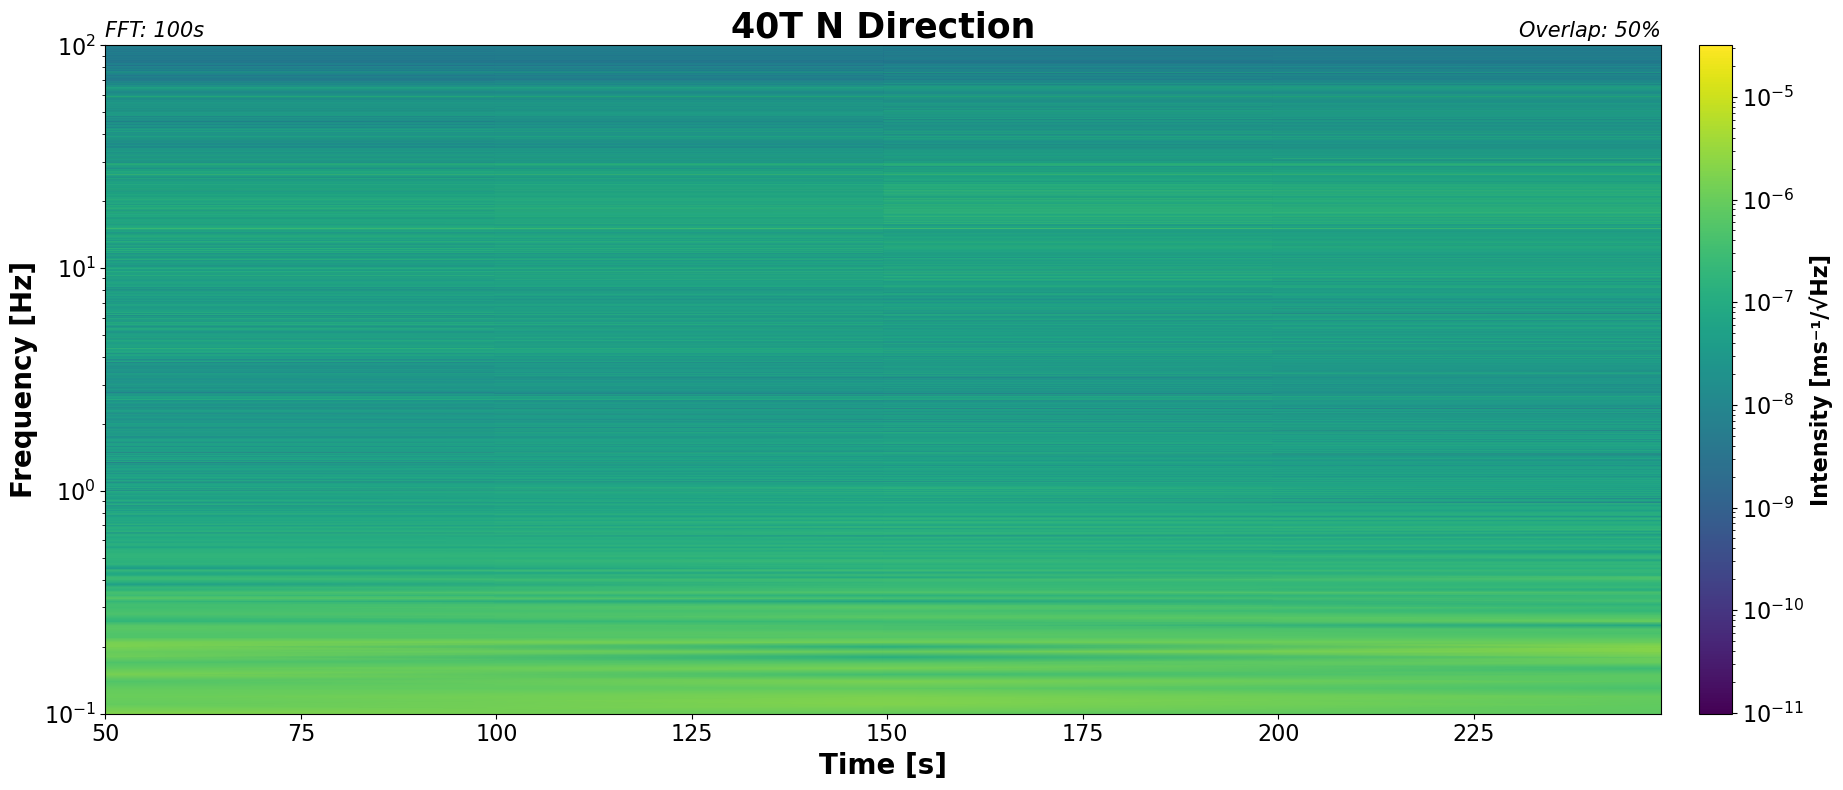

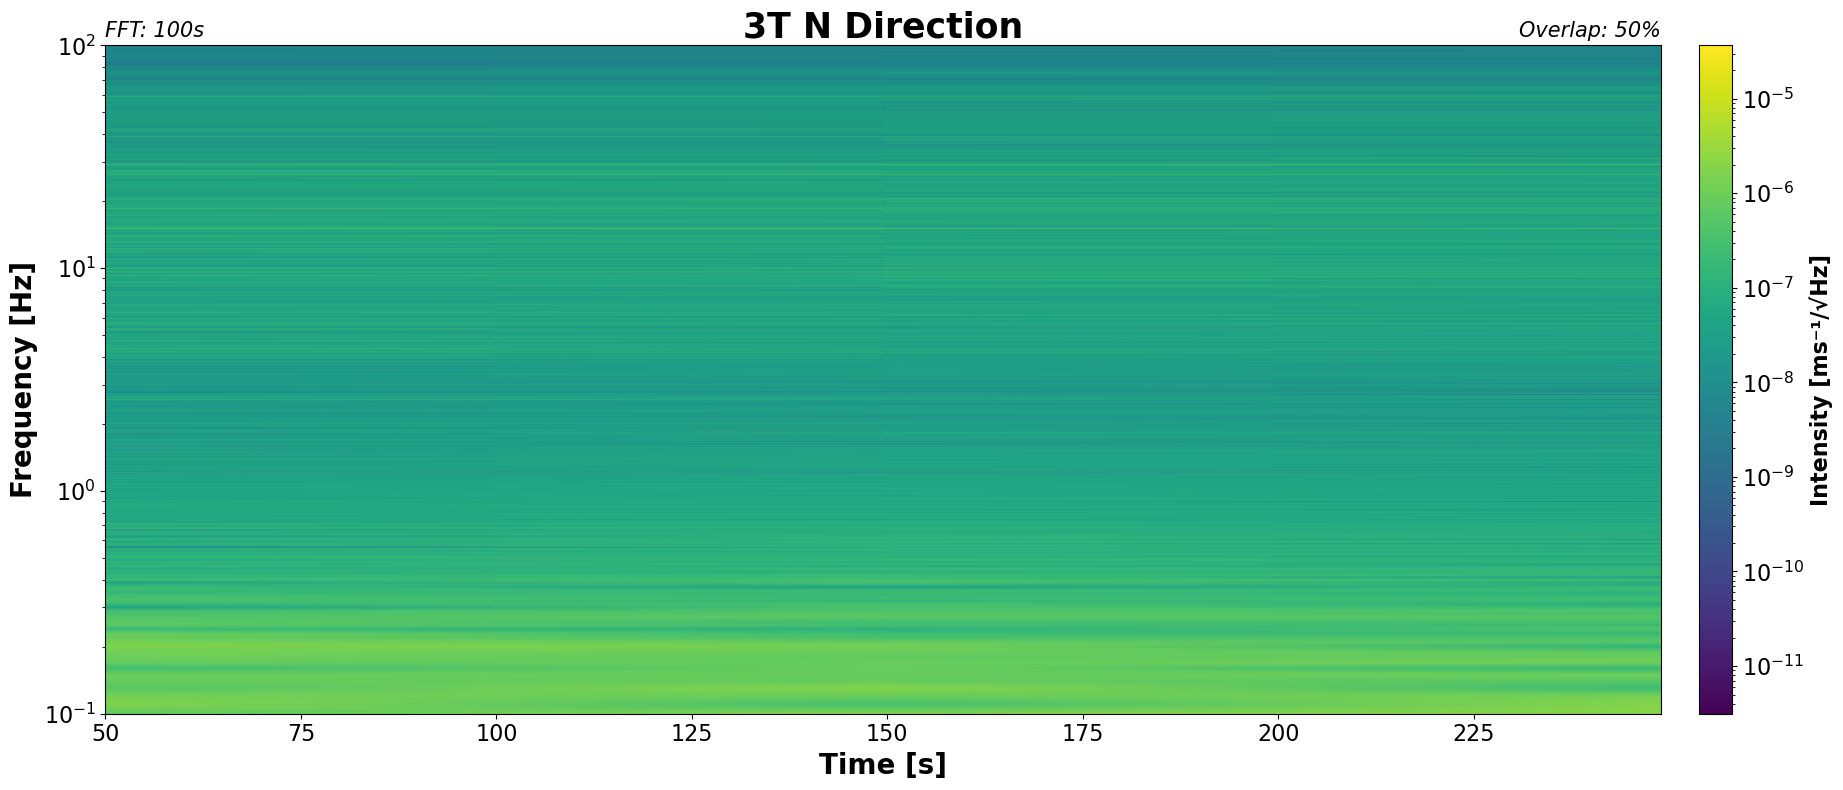

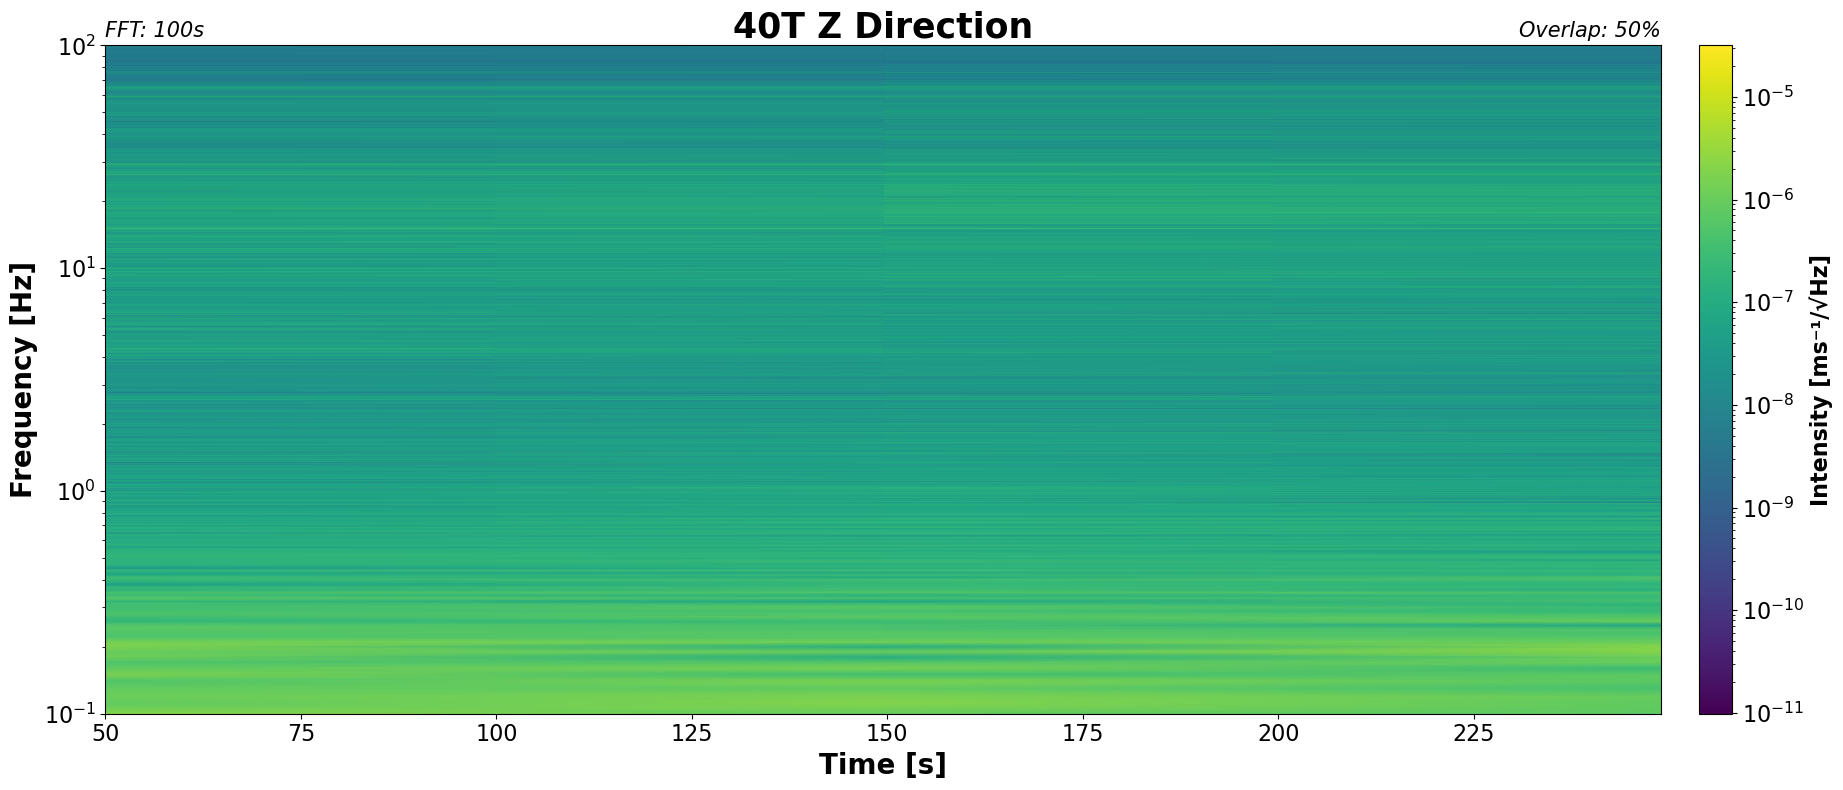

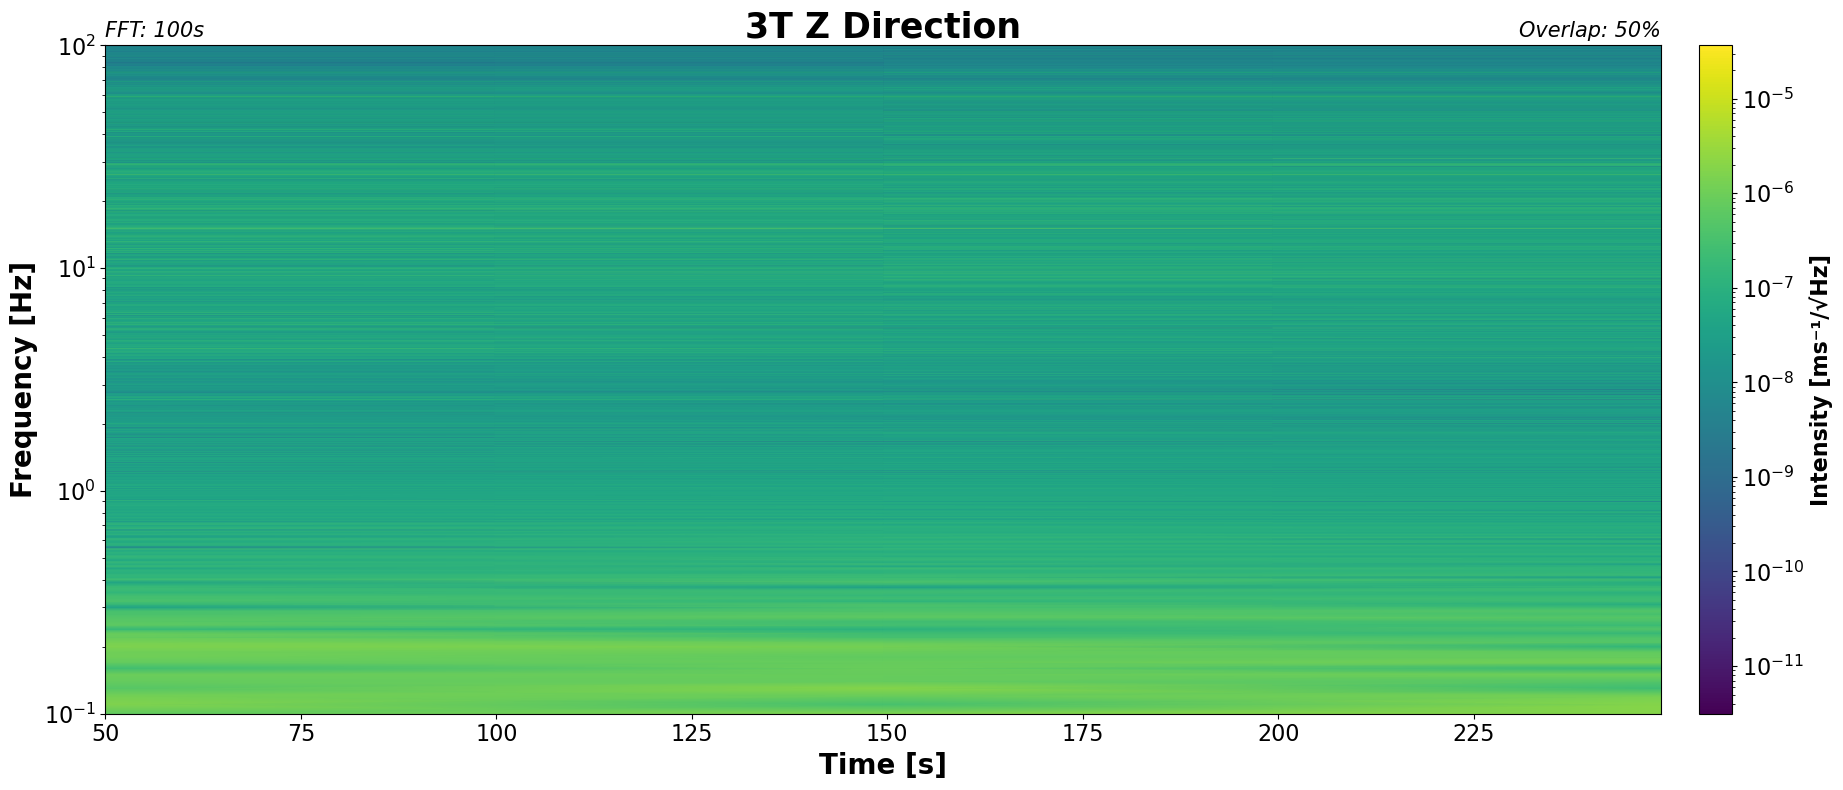

In [7]:
###--------------------------------------------------------------------------------------------------------------------------###


cmin = None
cmax = None  

## Plot limits
x_max_spectrogram = None
x_min_spectrogram = 0

y_max_spectrogram = 100
y_min_spectrogram = 0.1
fft_len = 100
overlap = 50

###--------------------------------------------------------------------------------------------------------------------------###

def spectrogram(data, channel, sample_rate, over_lap, fft, c_min, c_max, ymin, ymax, xmin, xmax, function):

    f, t, Sxx = signal.spectrogram(data, sample_rate, window= 'hamming', 
                                         nperseg = int(round(sample_rate * fft) ), 
                                         noverlap = int(round(sample_rate *(over_lap *0.01)) ) )

#------------------------------------------------------------------------------------------------------------------------------#

    channel_titles = {
        "40T": {"x": "40T E Direction", "y": "40T N Direction", "z": "40T Z Direction"},
        "3T":  {"x": "3T E Direction", "y": "3T N Direction", "z": "3T Z Direction"}}


    title = channel_titles.get(function, {}).get(channel, "Channel")
    cbar_units = "Intensity [ms⁻¹/√Hz]"

#------------------------------------------------------------------------------------------------------------------------------#

    fig = plt.figure(figsize = (20,8))

    gs = gridspec.GridSpec(1,1)

    axis1 = fig.add_subplot(gs[0,0])
    axis1.set_yscale('log')

    m0 = axis1.pcolormesh(t, f, np.sqrt(Sxx), shading = 'gouraud', norm = LogNorm(vmin = c_min, vmax = c_max))

    axis1.set_title('FFT: ' + str(fft) + "s", fontsize = 15, loc = "left",style ='italic')
    axis1.set_title("Overlap: " + str(over_lap) + "%", fontsize = 15, loc = "right",style ='italic')

    axis1.set_title(title, fontweight = 'bold' , fontsize = 25)
    axis1.set_xlabel('Time [s]', fontweight = 'bold' , fontsize = 20)
    axis1.set_ylabel('Frequency [Hz]', fontweight = 'bold' , fontsize = 20)
    axis1.tick_params(labelsize=16)

    cbar0 = fig.colorbar(m0, pad =0.02)
    cbar0.ax.tick_params(labelsize=16)
    cbar0.set_label(label= cbar_units ,weight='bold', fontsize = 16)
    cbar0.ax.yaxis.offsetText.set_fontsize(14)

    if xmin == None or xmin < t[0]:
        xmin = t[0]

    if xmax == None or xmax > t[-1]:
        xmax = t[-1]

    axis1.set_ylim(ymin,ymax) ## Uncomment to set limits
    axis1.set_xlim(xmin,xmax)
    plt.tight_layout()
    plt.show()

    
###--------------------------------------------------------------------------------------------------------------------------###
#---------------------------------------------------------- N Channel ---------------------------------------------------------#
###--------------------------------------------------------------------------------------------------------------------------###

spectrogram(frida_z, "y", sample_rate, overlap, fft_len, cmin, cmax, y_min_spectrogram, y_max_spectrogram, None, None, "40T")


spectrogram(blu_z, "y", sample_rate, overlap, fft_len, cmin, cmax, y_min_spectrogram, y_max_spectrogram, None, None, "3T")



###--------------------------------------------------------------------------------------------------------------------------###
#---------------------------------------------------------- Z Channel ---------------------------------------------------------#
###--------------------------------------------------------------------------------------------------------------------------###

spectrogram(frida_z, "z", sample_rate, overlap, fft_len, cmin, cmax, y_min_spectrogram, y_max_spectrogram, None, None, "40T")


spectrogram(blu_z, "z", sample_rate, overlap, fft_len, cmin, cmax, y_min_spectrogram, y_max_spectrogram, None, None, "3T")